In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [15]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
class NonLinearClassifier(nn.Module):
	def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(input_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, output_dim)
		)

	def forward(self, x):
		return self.net(x)

model = NonLinearClassifier()

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def train_model(model, X_train, y_train, epochs=500):
	model.train()
	losses = []
	for epoch in range(epochs):
		optimizer.zero_grad()
		outputs = model(X_train)
		loss = criterion(outputs, y_train)
		loss.backward()
		optimizer.step()
		losses.append(loss.item())
		if epoch % 100 == 0:
			print(f"Epoch: {epoch}, Loss: {loss.item()}:.4f")
	return losses

train_model(model, X_train, y_train, epochs=500)

Epoch: 0, Loss: 0.6955923438072205:.4f
Epoch: 100, Loss: 0.001984907314181328:.4f
Epoch: 200, Loss: 0.0006595905288122594:.4f
Epoch: 300, Loss: 0.00018538169388193637:.4f
Epoch: 400, Loss: 7.131030724849552e-05:.4f


[0.6955923438072205,
 0.6580941677093506,
 0.6240817904472351,
 0.5878864526748657,
 0.5500470995903015,
 0.5109723806381226,
 0.471380352973938,
 0.43176648020744324,
 0.3937442898750305,
 0.35884514451026917,
 0.3278141915798187,
 0.3010811507701874,
 0.27852359414100647,
 0.25948479771614075,
 0.2431579977273941,
 0.22868436574935913,
 0.21550139784812927,
 0.20342254638671875,
 0.1925077885389328,
 0.1827579140663147,
 0.17413707077503204,
 0.16648201644420624,
 0.15944935381412506,
 0.15275387465953827,
 0.146143838763237,
 0.1393059641122818,
 0.1319684535264969,
 0.12418157607316971,
 0.11611341685056686,
 0.10793695598840714,
 0.09988245368003845,
 0.09202566742897034,
 0.08443114161491394,
 0.07720918953418732,
 0.07043660432100296,
 0.06411699205636978,
 0.05825548619031906,
 0.052925512194633484,
 0.04815956577658653,
 0.04391375929117203,
 0.04019228368997574,
 0.03692822530865669,
 0.034002866595983505,
 0.03137427940964699,
 0.02895212359726429,
 0.026686251163482666,
 0.

/tmp/ipykernel_46709/3052859467.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(x_min, x_max, h),
/tmp/ipykernel_46709/3052859467.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


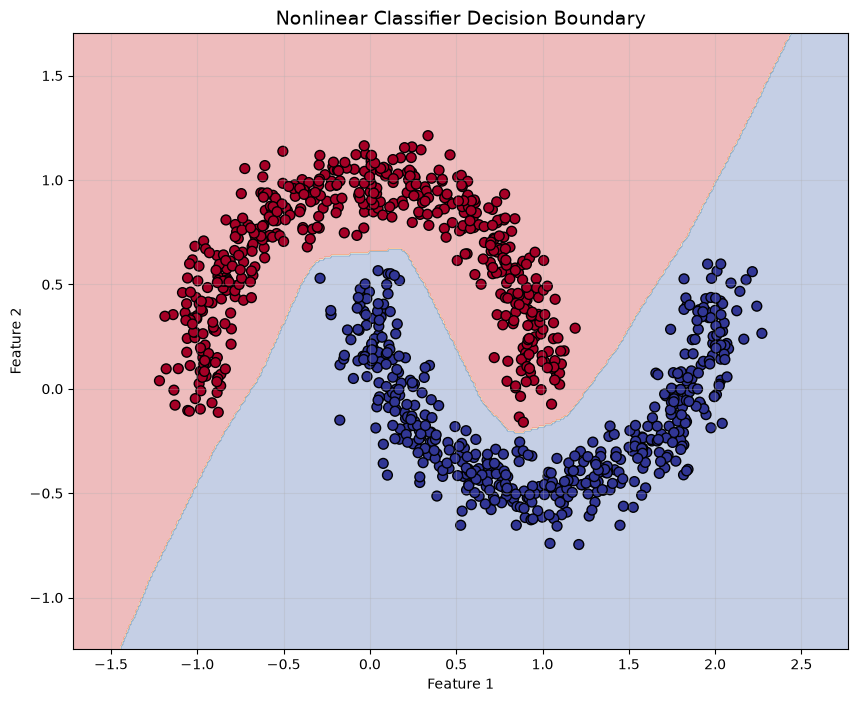

In [18]:
def plot_decision_boundary(model, X, y, title="Nonlinear Decision Boundary"):
	model.eval()

	x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
	y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

	h = 0.01
	xx, yy = np.meshgrid(
		np.arange(x_min, x_max, h),
		np.arange(y_min, y_max, h))

	grid_points = torch.tensor(
		np.c_[xx.ravel(), yy.ravel()],
		dtype=torch.float32)
	
	with torch.no_grad():
		Z = model(grid_points) # 模型的原始输出，也就是给(类别1，类别2)的打分
		_, Z = torch.max(Z, 1) # 从原始分数中找最大的那个类别索引
	z = Z.numpy().reshape(xx.shape)

	plt.figure(figsize=(10, 8))
	plt.contourf(xx, yy, z, alpha=0.3, cmap=plt.cm.RdYlBu) # 用两种颜色代表两种类别
	plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=50)
	plt.title(title, fontsize=14)
	plt.xlabel("Feature 1")
	plt.ylabel("Feature 2")
	plt.grid(alpha=0.3)
	plt.show()

plot_decision_boundary(model, X, y, title="Nonlinear Classifier Decision Boundary")

Epoch: 0, Loss: 0.4272198975086212:.4f
Epoch: 100, Loss: 0.4272198975086212:.4f
Epoch: 200, Loss: 0.4272198975086212:.4f
Epoch: 300, Loss: 0.4272198975086212:.4f
Epoch: 400, Loss: 0.4272198975086212:.4f


/tmp/ipykernel_46709/3052859467.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(x_min, x_max, h),
/tmp/ipykernel_46709/3052859467.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


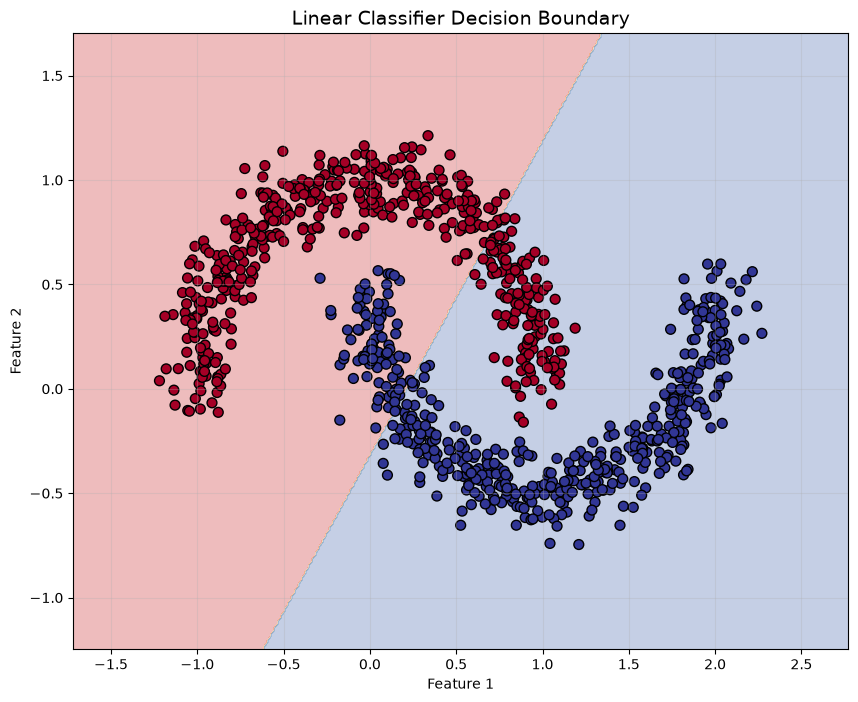

In [19]:
class LinearClassifier(nn.Module):
	def __init__(self, input_dim=2, output_dim=2):
		super().__init__()
		self.linear = nn.Linear(input_dim, output_dim)

	def forward(self, x):
		return self.linear(x)

linear_model = LinearClassifier()
optimizer_linear = optim.Adam(linear_model.parameters(), lr=0.01)
train_model(linear_model, X_train, y_train, epochs=500)

plot_decision_boundary(linear_model, X, y, title="Linear Classifier Decision Boundary")